In [1]:
import pickle
import glob
import random
import h5py
import numpy as np
import os

from scipy.special import eval_hermite

import scfitpy
from scfitpy.image_processing import (
    apply_sato_filter,
    find_contours,
    assign_contours,
    determine_regions,
    determine_peak_positions,
)

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
# Configure matplotlib 
plt.rcParams["font.size"] = 25
plt.rcParams["mathtext.fontset"] = "stix"

In [3]:
# Load test spectrum
_dat = np.load("./assets/cwSpec_currentSweep_202407011423.npz")
current = _dat["current"]  # mA
freq = _dat["freq"]  # GHz

mag1 = _dat["mag1"].T  # 2d-spectrum date, dims=[freq, current]

print(f"{mag1.shape=} {current.shape=} {freq.shape=}")

mag1.shape=(260, 800) current.shape=(800,) freq.shape=(260,)


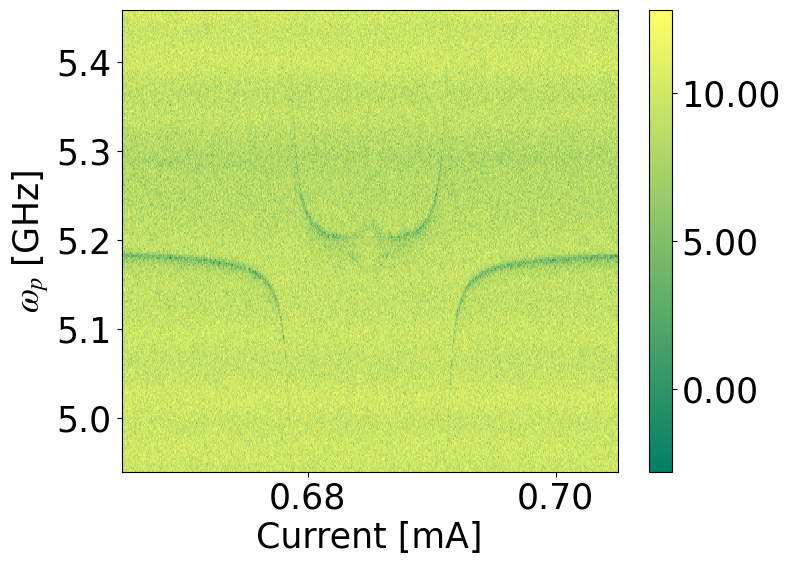

In [4]:
# Check the spectrum
fig, ax = plt.subplots(figsize=(8, 6))

X, Y = np.meshgrid(current, freq)
mappable = ax.pcolor(X, Y, mag1, cmap="summer")
cbar = plt.colorbar(mappable, ax=ax, format="%.2f")

plt.xlabel(r"Current [mA]")
plt.ylabel(r"$\omega_p\ $[GHz]")
plt.show()

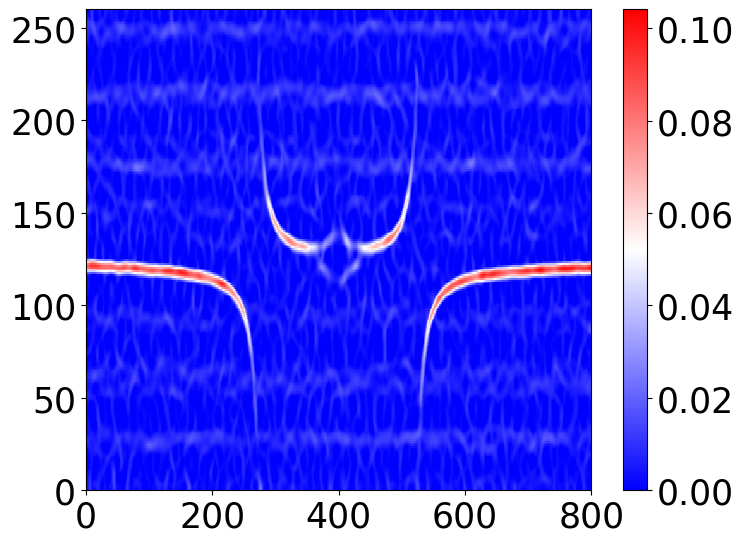

In [5]:
mag1_filtered = apply_sato_filter(
    mag1, 4, black_ridges=True, with_plot=True, filename_plot="./outs/sato.png"
)

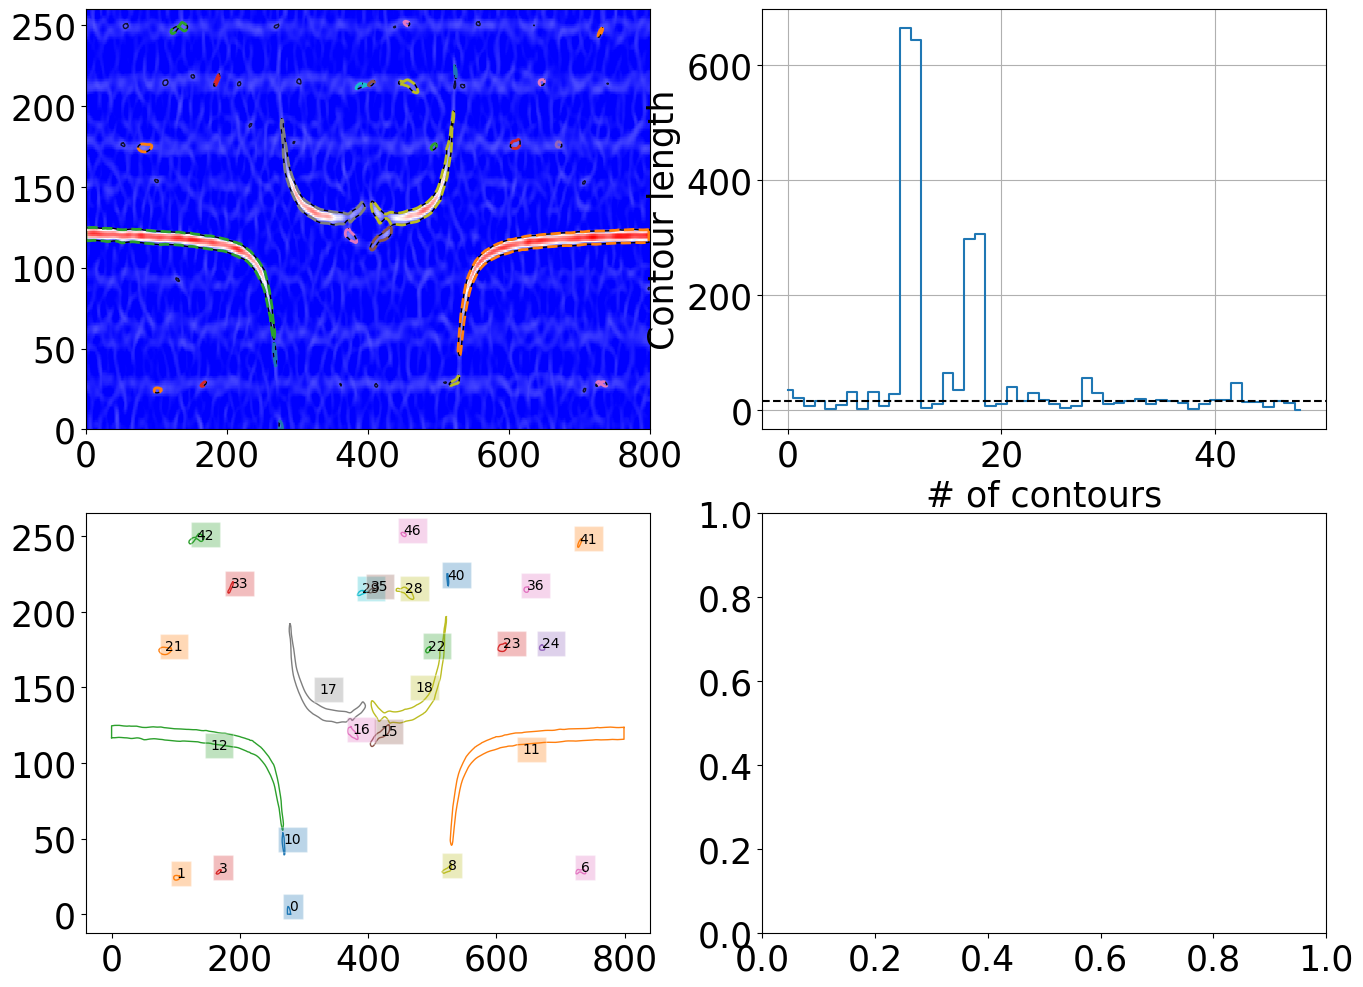

# of contours: 49


In [6]:
cont_list = find_contours(
    mag1_filtered, level=0.016, with_plot=True, filename_plot="./outs/cont.png"
)
print(f"# of contours: {len(cont_list)}")

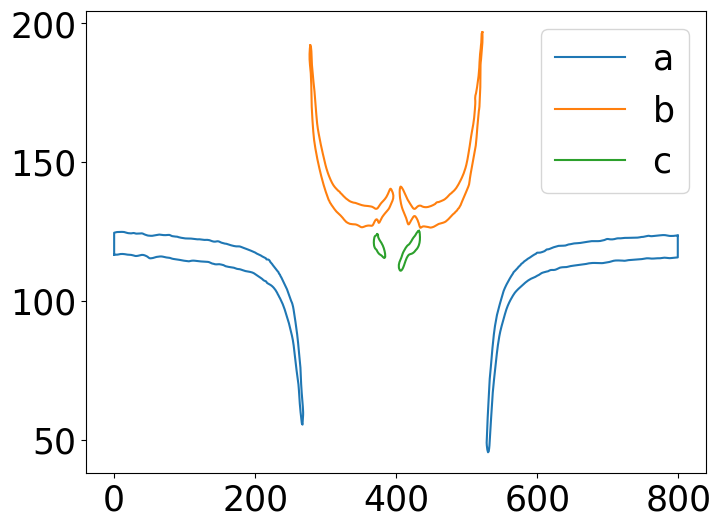

In [7]:
cont_dict = assign_contours(
    cont_list,
    dict(
        a=(12, 11), b=(17, 18), c=(16, 15)
    ), 
    with_plot=True,
    filename_plot="./outs/cont_assignments.png",
)

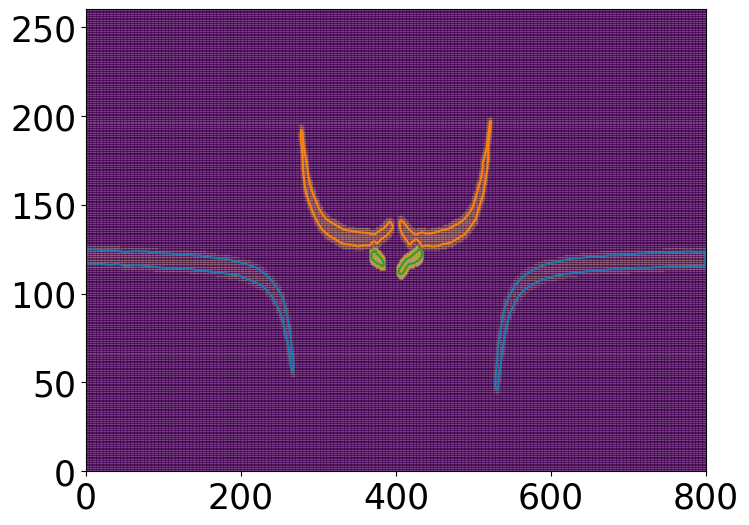

In [8]:
region_dict = determine_regions(mag1, cont_dict, 5, with_plot=True)

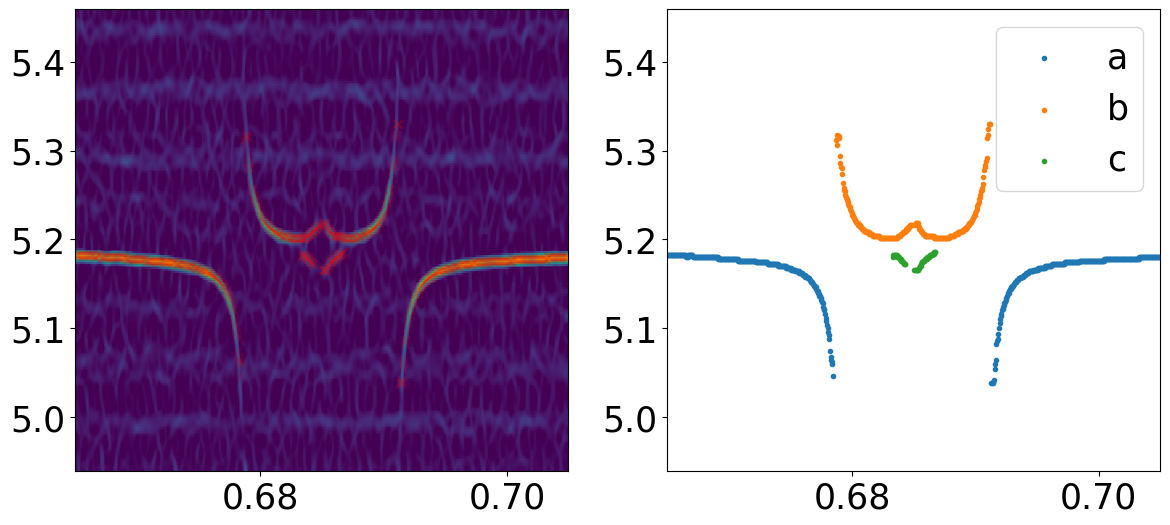

band:a --> (xval,yval)=[[0.665      5.182     ]
 [0.66505    5.182     ]
 [0.6651     5.182     ]
 ...
 [0.70485    5.1800003 ]
 [0.7049     5.1800003 ]
 [0.70495003 5.1800003 ]]
band:b --> (xval,yval)=[[0.6787     5.312     ]
 [0.67875    5.3059998 ]
 [0.6788     5.318     ]
 [0.67885    5.3159995 ]
 [0.6789     5.3159995 ]
 [0.67895    5.3139997 ]
 [0.67899996 5.294     ]
 [0.67904997 5.286     ]
 [0.6791     5.2819996 ]
 [0.67915    5.2799997 ]
 [0.6792     5.2739997 ]
 [0.67925    5.264     ]
 [0.6793     5.258     ]
 [0.67935    5.256     ]
 [0.67939997 5.254     ]
 [0.67945    5.2499995 ]
 [0.6795     5.2479997 ]
 [0.67955    5.246     ]
 [0.6796     5.244     ]
 [0.67965    5.2419996 ]
 [0.6797     5.24      ]
 [0.67974997 5.238     ]
 [0.6798     5.2359996 ]
 [0.67985    5.2339997 ]
 [0.6799     5.232     ]
 [0.67995    5.23      ]
 [0.68       5.228     ]
 [0.68005    5.226     ]
 [0.6801     5.226     ]
 [0.68015    5.224     ]
 [0.6802     5.222     ]
 [0.68025    5.222     

In [9]:
peak_dict = determine_peak_positions(
    mag1_filtered,
    region_dict,
    xaxis=current,
    yaxis=freq,
    with_plot=True,
)

for kw, pos in peak_dict.items():
    print(f'band:{kw} --> (xval,yval)={pos}')

In [10]:
os.chdir(".\outs")
with open('peak_dict.pkl', 'wb') as file:
    pickle.dump(peak_dict, file)